
**Asignatura:** Teoria de la Distribucion y Probabilidad
**Ciclo:** Segundo Ciclo  
**Realizado por:** Ariana Quezada



# **Tarea 1: Configuracion del Entorno**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, norm, binom, uniform
import seaborn as sns

# Configuracion de estilo
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Entorno configurado correctamente")


Entorno configurado correctamente


# **Tarea 2: Variable Aleatoria Discreta - Lanzamiento de Dado**

Caso: X = resultado del lanzamiento de un dado justo.

2.	Defina la variable aleatoria y su PMF:

In [ ]:
# Variable aleatoria: resultado de un dado
# X puede tomar valores: 1, 2, 3, 4, 5, 6

# Valores posibles
x_valores = np.array([1, 2, 3, 4, 5, 6])

# PMF: cada valor tiene probabilidad 1/6
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

print("Valores de X:", x_valores)
print("PMF p(x):", pmf_dado)
print("Suma de probabilidades:", np.sum(pmf_dado))


Valores de X: [1 2 3 4 5 6]
PMF p(x): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Suma de probabilidades: 0.9999999999999999


3.	Visualice la PMF:

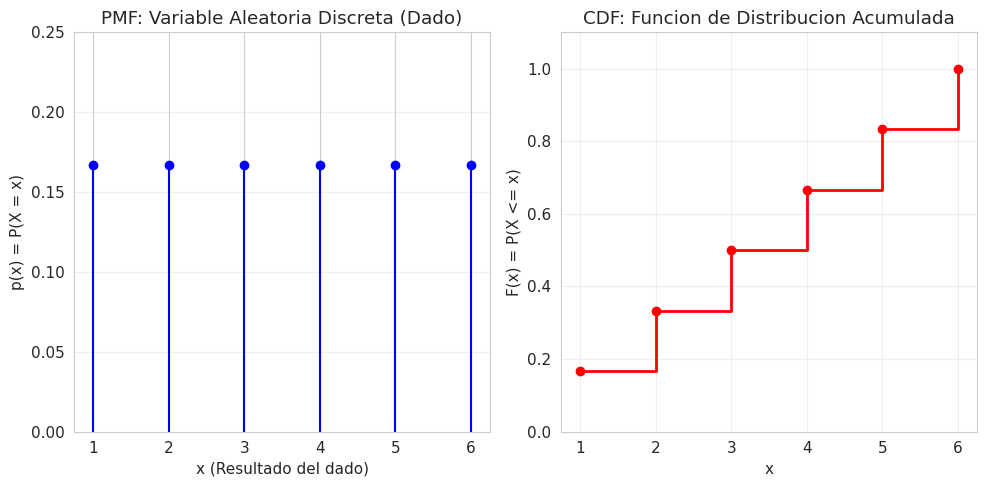

In [ ]:
# Visualizacion de la PMF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)

# CDF
cdf_dado = np.cumsum(pmf_dado)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Funcion de Distribucion Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


4.	Calcule probabilidades especificas:

In [ ]:
# a) P(X = 4)
prob_4 = pmf_dado[x_valores == 4][0]
print(f"P(X = 4) = {prob_4:.4f}")

# b) P(X <= 3) usando CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]
print(f"P(X <= 3) = {prob_menor_3:.4f}")

# c) P(2 <= X <= 5)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]
print(f"P(2 <= X <= 5) = {prob_entre_2_5:.4f}")


P(X = 4) = 0.1667
P(X <= 3) = 0.5000
P(2 <= X <= 5) = 0.6667


# **Tarea 3: Variable Aleatoria Continua - Distribucion Normal**

Caso: X = tiempo de respuesta de un servidor (ms), distribuido normalmente con mu = 200 y sigma = 30.

5.	Defina la distribucion y visualice la PDF:

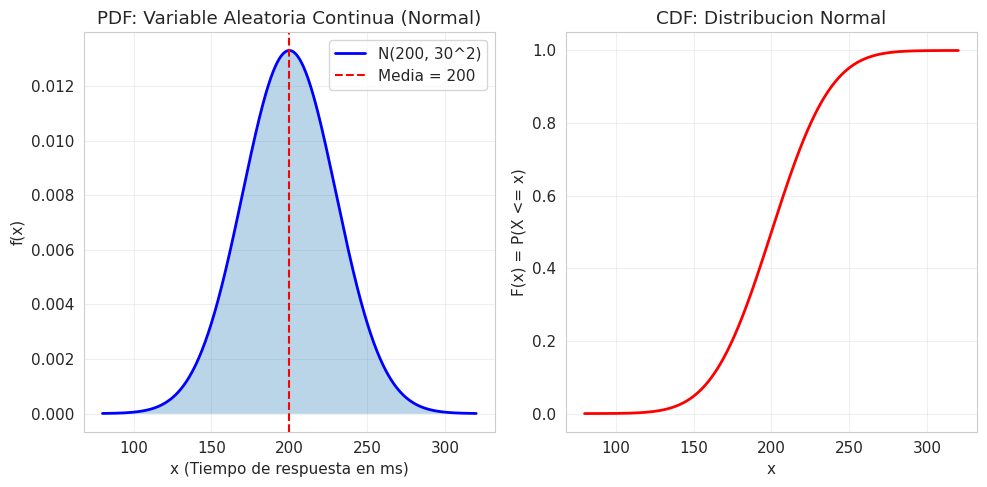

In [ ]:
# Parametros de la distribucion normal
mu = 200  # media
sigma = 30  # desviacion estandar

# Crear la distribucion
dist_normal = norm(loc=mu, scale=sigma)

# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# PDF
pdf_normal = dist_normal.pdf(x)

# Visualizacion
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.axvline(mu, color='red', linestyle='--', label=f'Media = {mu}')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x)')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_normal = dist_normal.cdf(x)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_normal, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Distribucion Normal')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


6.	Calcule probabilidades:

In [ ]:
# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)
print(f"P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")

# b) P(X > 250)
prob_mayor_250 = 1 - dist_normal.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")

# c) P(170 <= X <= 230)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)
print(f"P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")

# d) Percentil 95
p95 = dist_normal.ppf(0.95)
print(f"\nPercentil 95: {p95:.2f} ms")
print(f"El 95% de los tiempos de respuesta son menores a {p95:.2f} ms")


P(X <= 180) = 0.2525 (25.25%)
P(X > 250) = 0.0478 (4.78%)
P(170 <= X <= 230) = 0.6827 (68.27%)

Percentil 95: 249.35 ms
El 95% de los tiempos de respuesta son menores a 249.35 ms


# **Tarea 4: Comparacion Visual PMF vs PDF**

7.	Cree una visualizacion comparativa:

In [ ]:
# Comparacion PMF vs PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variable Discreta (Dado)
axes[0].stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Funcion de Masa de Probabilidad')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)

# Anotaciones
axes[0].annotate('Probabilidad en\npuntos especificos', xy=(3, 1/6), xytext=(4.5, 0.2),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# Variable Continua (Normal)
axes[1].plot(x, pdf_normal, 'b-', linewidth=2)
axes[1].fill_between(x, pdf_normal, alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Funcion de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)

# Anotaciones
axes[1].annotate('Probabilidad = Area\nbajo la curva', xy=(200, norm.pdf(200, 200, 30)), xytext=(250, 0.01),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.suptitle('Comparacion: Variable Aleatoria Discreta vs Continua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# **Tarea 5: Aplicacion - Variables Aleatorias en la UNL**

***8.	En su grupo, identifique 5 variables aleatorias en diferentes areas de la UNL:***

•	Biblioteca: _________________________________________________

•	Cafeteria: _________________________________________________

•	Laboratorios: ______________________________________________

•	Estacionamiento: ___________________________________________

•	Aulas de clase: ____________________________________________

***9.	Para cada variable, determine:***

•	Tipo: Discreta / Continua

•	Posibles valores que puede tomar

•	Distribucion de probabilidad esperada (si se puede inferir)

***10.	Complete la tabla de registro:***


In [ ]:
import pandas as pd

# 1. Configuración para separar y organizar las columnas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.unicode.east_asian_width', True) # Ayuda con el alineamiento

# 2. Plantilla con encabezados en MAYÚSCULAS
variables_unl = [
    {
        'NOMBRE': 'Ingreso de estudiantes/hora',
        'UBICACION': 'Biblioteca Central',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0, 1, 2, 3...',
        'DISTRIBUCION ESPERADA': 'Poisson'
    },
    {
        'NOMBRE': 'Tiempo de espera en fila',
        'UBICACION': 'Cafetería Central',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '0 a 15 minutos',
        'DISTRIBUCION ESPERADA': 'Exponencial'
    },
    {
        'NOMBRE': 'Equipos operativos',
        'UBICACION': 'Lab. Computación',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0 a 30 equipos',
        'DISTRIBUCION ESPERADA': 'Binomial'
    },
    {
        'NOMBRE': 'Vehículos estacionados',
        'UBICACION': 'Estacionamiento UNL',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0 a 50 vehículos',
        'DISTRIBUCION ESPERADA': 'Binomial'
    },
    {
        'NOMBRE': 'Estatura de estudiantes',
        'UBICACION': 'Aulas de clase',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '1.50m a 1.95m',
        'DISTRIBUCION ESPERADA': 'Normal'
    }
]

df = pd.DataFrame(variables_unl)

# 3. El truco para el espacio: Col_space añade pixeles/caracteres de separación
# 'justify' centra los encabezados y 'col_space' separa las columnas
print(df.to_string(index=False, justify='center', col_space=25))

           NOMBRE                   UBICACION                    TIPO                VALORES POSIBLES       DISTRIBUCION ESPERADA  
Ingreso de estudiantes/hora     Biblioteca Central             Discreta                 0, 1, 2, 3...                Poisson       
   Tiempo de espera en fila      Cafetería Central             Continua                0 a 15 minutos            Exponencial       
         Equipos operativos       Lab. Computación             Discreta                0 a 30 equipos               Binomial       
     Vehículos estacionados    Estacionamiento UNL             Discreta              0 a 50 vehículos               Binomial       
    Estatura de estudiantes         Aulas de clase             Continua                 1.50m a 1.95m                 Normal       


#***TRABAJO AUTONOMO***

***11.	Modifique el codigo de la Tarea 3 para representar una variable de su eleccion:***

•	Opcion A: Distribución Bernoulli (lanzamiento de moneda)

•	Opcion B: Distribución Uniforme discreta

•	Opcion C: Distribución Binomial

•	Genere las gráficas PMF/PDF y CDF para su distribución seleccionada.

•	Calcule al menos 3 probabilidades especificas e interprete los resultados


**•	Entregue un archivo. ipynb con:**

•	Código funcional y comentado

•	Visualizaciones claras

•	Interpretación de resultados


## 👤 Ariana Quezada
**Distribución Elegida:** Distribución Uniforme Discreta (Opcion B)

**Justificación:** He seleccionado la Distribución Uniforme Discreta porque permite modelar situaciones donde todos los eventos de un conjunto finito tienen la misma probabilidad de ocurrir. En mi código, he aplicado este modelo a la asignación de aulas en la UNL, definiendo un rango de 1 a 10. Bajo este modelo, cada aula tiene una probabilidad exacta de 10% ($1/10$) de ser seleccionada. Esta elección es ideal porque garantiza un proceso de distribución de recursos totalmente equitativo y aleatorio, asegurando que no existan preferencias ni sesgos al momento de asignar un espacio físico para las actividades académicas.

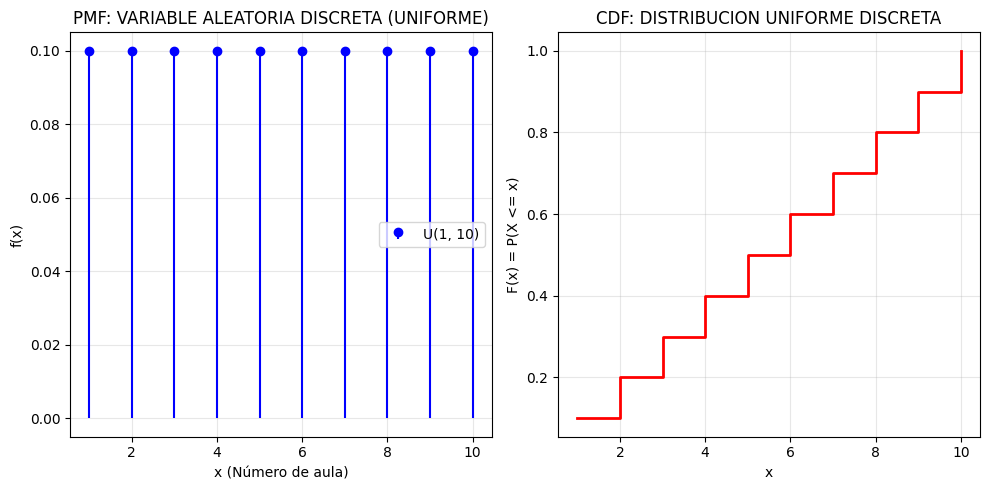

            ANÁLISIS DE PROBABILIDADES            
--------------------------------------------------
a) P(X = 5) = 0.1000 (10.00%)
Interpretación: Existe una probabilidad igualitaria para cada aula seleccionada.

b) P(X <= 4) = 0.4000 (40.00%)
Interpretación: Hay un 40% de probabilidad de que el valor sea 4 o menor.

c) P(2 <= X <= 7) = 0.6000 (60.00%)
Interpretación: Probabilidad acumulada dentro del rango intermedio de aulas.

Percentil 95: 10
Interpretación: El 95% de los resultados posibles son menores o iguales a 10.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint

# PARAMETROS DE LA DISTRIBUCION UNIFORME DISCRETA (Literal 11 - Opción B)
bajo = 1
alto = 11  # El límite superior es exclusivo

# Crear la distribucion
dist_uniforme = randint(bajo, alto)

# Rango de valores para graficar
x = np.arange(bajo, alto)

# PMF (Equivalente a PDF para variables discretas)
pdf_uniforme = dist_uniforme.pmf(x)

# Visualizacion
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
# Usamos stem para representar la naturaleza discreta de la variable
plt.stem(x, pdf_uniforme, linefmt='b-', markerfmt='bo', basefmt=" ", label='U(1, 10)')
plt.xlabel('x (Número de aula)')
plt.ylabel('f(x)')
plt.title('PMF: VARIABLE ALEATORIA DISCRETA (UNIFORME)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_uniforme = dist_uniforme.cdf(x)
plt.subplot(1, 2, 2)
# Gráfica de pasos (escalonada) ideal para distribuciones discretas
plt.step(x, cdf_uniforme, 'r-', linewidth=2, where='post')
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: DISTRIBUCION UNIFORME DISCRETA')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ANALISIS DE RESULTADOS E INTERPRETACION
print(f"{'ANÁLISIS DE PROBABILIDADES':^50}")
print("-" * 50)

# a) P(X = 5)
prob_exacta = dist_uniforme.pmf(5)
print(f"a) P(X = 5) = {prob_exacta:.4f} ({prob_exacta*100:.2f}%)")
print("Interpretación: Existe una probabilidad igualitaria para cada aula seleccionada.")

# b) P(X <= 4)
prob_menor_4 = dist_uniforme.cdf(4)
print(f"\nb) P(X <= 4) = {prob_menor_4:.4f} ({prob_menor_4*100:.2f}%)")
print(f"Interpretación: Hay un {prob_menor_4*100:.0f}% de probabilidad de que el valor sea 4 o menor.")

# c) P(2 <= X <= 7)
prob_rango = dist_uniforme.cdf(7) - dist_uniforme.cdf(1)
print(f"\nc) P(2 <= X <= 7) = {prob_rango:.4f} ({prob_rango*100:.2f}%)")
print("Interpretación: Probabilidad acumulada dentro del rango intermedio de aulas.")

# d) Percentil 95
p95 = dist_uniforme.ppf(0.95)
print(f"\nPercentil 95: {p95:.0f}")
print(f"Interpretación: El 95% de los resultados posibles son menores o iguales a {p95:.0f}.")

#**7. Preguntas de Control**

### **1. ¿Cuál es la diferencia fundamental entre una variable aleatoria discreta y una continua?**

*   **Variable Aleatoria Discreta:** Es aquella que solo puede tomar valores aislados y contables, generalmente números enteros. Un ejemplo dentro de la carrera es el **número de estudiantes** que llegan tarde o el **número de equipos** en un laboratorio.
*   **Variable Aleatoria Continua:** Es aquella que puede tomar cualquier valor dentro de un intervalo real, incluyendo una cantidad infinita de decimales. Ejemplos comunes son la **estatura** de una persona o el **tiempo de ejecución** de un proceso en milisegundos.


### **2. ¿Por qué en una variable continua $P(X = x) = 0$ para cualquier valor específico $x$?**
*   En las distribuciones continuas, la probabilidad se mide como el **área bajo la curva** en un intervalo determinado.
*   Debido a que un punto exacto carece de ancho (base = 0), el área en ese punto es matemáticamente cero. Por lo tanto, la probabilidad solo tiene sentido cuando se calcula en rangos.

### **3. Explique la relación entre la PMF/PDF y la CDF. ¿Cómo se obtiene una de la otra?**
La **PMF/PDF** indica la probabilidad o densidad en puntos específicos, mientras que la **CDF** representa la probabilidad acumulada hasta un valor $x$.
*   **Para obtener la CDF:** Se deben sumar (discreta) o integrar (continua) los valores de la PMF/PDF.
*   **Para obtener la PMF/PDF:** Se calcula la diferencia entre puntos sucesivos (discreta) o se deriva la función CDF (continua).


### **4. Una variable aleatoria $X$ representa el número de estudiantes que llegan tarde a clase. ¿Es $X$ discreta o continua? Justifique.**

* **Respuesta:** Es **Discreta**.
>
>* **Justificación:** El número de personas es una cantidad contable que no admite valores decimales. Los resultados posibles se limitan a números enteros (0, 1, 2, etc.).

### **5. Calcule $P(X = 5)$ para una variable continua con PDF $f(x) = 2x$ en $[0,1]$. Explique su respuesta.**

*   **Resultado:** $P(X = 5) = 0$
>*   **Explicación:** Por definición, la probabilidad de cualquier punto exacto en una variable continua es siempre cero. Además, en este caso particular, el valor $x = 5$ se encuentra fuera del rango de definición $[0, 1]$ de la función.


### **6. Dibuje aproximadamente la CDF de una variable discreta que toma valores {1, 2, 3} con probabilidades {0.3, 0.5, 0.2}.**
La gráfica resultante es **escalonada** (steps):
*   $F(x) = 0$ para $x < 1$
*   $F(x) = 0.3$ para $1 \le x < 2$
*   $F(x) = 0.8$ para $2 \le x < 3$
*   $F(x) = 1.0$ para $x \ge 3$

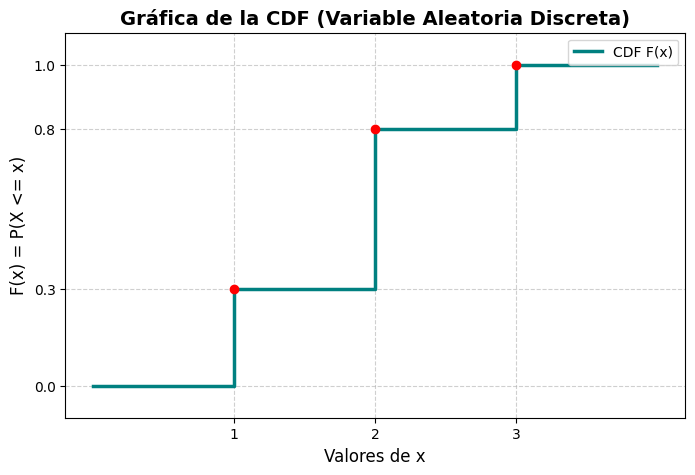

In [ ]:
import matplotlib.pyplot as plt

# Datos del ejercicio
x_val = [0, 1, 2, 3, 4] # Rango de valores para ver los escalones
y_val = [0, 0.3, 0.8, 1.0, 1.0] # Probabilidades acumuladas F(x)

plt.figure(figsize=(8, 5))

# Grafica de pasos (CDF)
# 'where=post' asegura que el salto ocurra exactamente en el valor de x
plt.step(x_val, y_val, where='post', color='teal', linewidth=2.5, label='CDF F(x)')

plt.title('Gráfica de la CDF (Variable Aleatoria Discreta)', fontsize=14, fontweight='bold')
plt.xlabel('Valores de x', fontsize=12)
plt.ylabel('F(x) = P(X <= x)', fontsize=12)
plt.xticks([1, 2, 3]) # Marcar solo los puntos relevantes
plt.yticks([0, 0.3, 0.8, 1.0])
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-0.1, 1.1)
plt.legend()

# Agregar puntos para resaltar el inicio de cada escalón
plt.plot([1, 2, 3], [0.3, 0.8, 1.0], 'ro')

plt.show()

### **7. Identifique una variable aleatoria continua en el contexto de la carrera de Computación y justifique porque es continua.**

*   **Variable:** El tiempo de respuesta (latencia) de un servidor en milisegundos.
>*   **Justificación:** Es continua porque el tiempo puede tomar cualquier valor real (ej. 15.452 ms) y puede medirse con precisión decimal infinita dentro de un intervalo de tiempo dado.

#  **8. Conclusiones y Recomendaciones**

## **Conclusiones**
*   Se logró implementar con éxito la **Distribución Uniforme Discreta** mediante la librería `scipy.stats`, permitiendo modelar la asignación equitativa de recursos (aulas) en el contexto académico de la **UNL**.
*   A través de las visualizaciones de la **PMF** (Función de Masa de Probabilidad) y la **CDF** (Función de Distribución Acumulada), se identificó claramente la naturaleza saltatoria y discreta de la variable, diferenciándola de modelos continuos.
*   El análisis estadístico confirmó que, en una distribución uniforme, cada evento dentro del rango definido $[1, 10]$ posee una probabilidad idéntica del **10%**, lo que garantiza un proceso de selección sin sesgos ni preferencias.

## **Recomendaciones**
*   Se sugiere ampliar el modelo para incluir variables con diferentes pesos de probabilidad, utilizando distribuciones como la **Binomial** o **Poisson**, para comparar la eficiencia en la gestión de recursos.
*   Es recomendable utilizar gráficos de tipo `stem` o `step` en Python al trabajar con variables discretas para evitar interpretaciones erróneas de continuidad en los datos.
*   Para proyectos futuros en la carrera de **Computación**, se propone integrar estos modelos probabilísticos en simulaciones de tráfico de red o tiempos de espera en servidores.


# **9. Bibliografía**


*   **Devore, J. L.** (2016). *Probabilidad y Estadística para Ingeniería y Ciencias* (9va ed.). Cengage Learning.
*   **SciPy Community.** (2024). *Statistical functions (scipy.stats)*. Recuperado de [https://docs.scipy.org/doc/scipy/reference/stats.html](https://docs.scipy.org/doc/scipy/reference/stats.html)
*   **Walpole, R. E., Myers, R. H., & Myers, S. L.** (2012). *Probabilidad y Estadística para Ingeniería y Ciencias*. Pearson Educación.